# 01 — Feature Engineering

Tier 1 (classic) features + Track A/B targets. Run `build_features.py` first, then inspect outputs here.

In [1]:
import os, sys
sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

OUT_DIR = '../data/processed'


## 1. Run the Feature Build Script

This caches `daily_ohlcv.parquet` and writes `features_tier1.parquet`. Takes ~10 min on first run (rolling OLS); subsequent runs are instant via cache.

In [2]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '../src/features/build_features.py'],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr[-3000:])


=== Week 2: Tier 1 Feature Engineering ===

SP500 union tickers (2010-2024): 674
  [cache] Loading daily OHLCV from /Users/paritoshdwivedi/ML_Paper/data/processed/daily_ohlcv.parquet
Daily OHLCV: (2612171, 7)  (661 tickers)

Building Tier 1 features...
  Done in 18s  →  (2612151, 16)

Computing Track B (raw 5d forward return)...

Computing Track A (idiosyncratic 5d forward return)...
  Computing daily idio returns (rolling OLS)...
  Done in 4s

=== Output ===
Shape:      (2611491, 18)
Date range: 2010-01-04 → 2024-12-31
Tickers:    660

Feature NaN rates:
ret_1d                 0.000
ret_5d                 0.001
ret_21d                0.005
ret_63d                0.016
ret_252d               0.063
mom_12_1               0.063
reversal_1w            0.001
reversal_4w            0.005
vol_21d                0.005
sharpe_21d             0.005
amihud                 0.005
roll_spread            0.000
vix                    0.000
vix_chg_5d             0.001
term_spread            0.000
ter

## 2. Load & Inspect Feature Matrix

In [3]:
feat = pd.read_parquet(f'{OUT_DIR}/features_tier1.parquet')
feat_cols = [c for c in feat.columns if not c.startswith('target')]
target_cols = ['target_track_b', 'target_track_a']

print(f'Shape: {feat.shape}')
print(f'Features ({len(feat_cols)}): {feat_cols}')
print(f'\nDate range: {feat.index.get_level_values("date").min().date()} → {feat.index.get_level_values("date").max().date()}')
print(f'Tickers: {feat.index.get_level_values("ticker").nunique()}')
print(f'\nFeature NaN rates (%):')
print((feat[feat_cols].isna().mean() * 100).round(1).to_string())
print(f'\nTarget coverage:')
print(feat[target_cols].notna().mean().round(3).to_string())


Shape: (2611491, 18)
Features (16): ['ret_1d', 'ret_5d', 'ret_21d', 'ret_63d', 'ret_252d', 'mom_12_1', 'reversal_1w', 'reversal_4w', 'vol_21d', 'sharpe_21d', 'amihud', 'roll_spread', 'vix', 'vix_chg_5d', 'term_spread', 'term_spread_chg_21d']

Date range: 2010-01-04 → 2024-12-31
Tickers: 660

Feature NaN rates (%):
ret_1d                 0.0
ret_5d                 0.1
ret_21d                0.5
ret_63d                1.6
ret_252d               6.3
mom_12_1               6.3
reversal_1w            0.1
reversal_4w            0.5
vol_21d                0.5
sharpe_21d             0.5
amihud                 0.5
roll_spread            0.0
vix                    0.0
vix_chg_5d             0.1
term_spread            0.0
term_spread_chg_21d    0.6

Target coverage:


target_track_b    0.993
target_track_a    0.258


## 3. Target Distributions

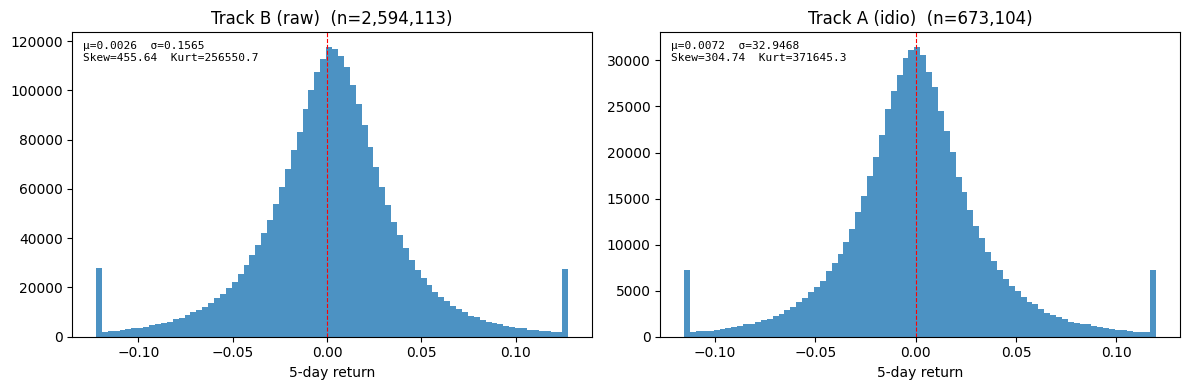

Saved target_distributions.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, target_cols, ['Track B (raw)', 'Track A (idio)']):
    data = feat[col].dropna()
    # Winsorise at 1/99 for display
    lo, hi = data.quantile(0.01), data.quantile(0.99)
    data_w = data.clip(lo, hi)
    ax.hist(data_w, bins=80, edgecolor='none', alpha=0.8)
    ax.set_title(f'{label}  (n={len(data):,})')
    ax.set_xlabel('5-day return')
    ax.axvline(0, color='red', linewidth=0.8, linestyle='--')
    stats = f'μ={data.mean():.4f}  σ={data.std():.4f}\nSkew={data.skew():.2f}  Kurt={data.kurtosis():.1f}'
    ax.text(0.02, 0.97, stats, transform=ax.transAxes, va='top', fontsize=8, family='monospace')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/target_distributions.png', dpi=120)
plt.show()
print('Saved target_distributions.png')


## 4. Feature Correlation Heatmap

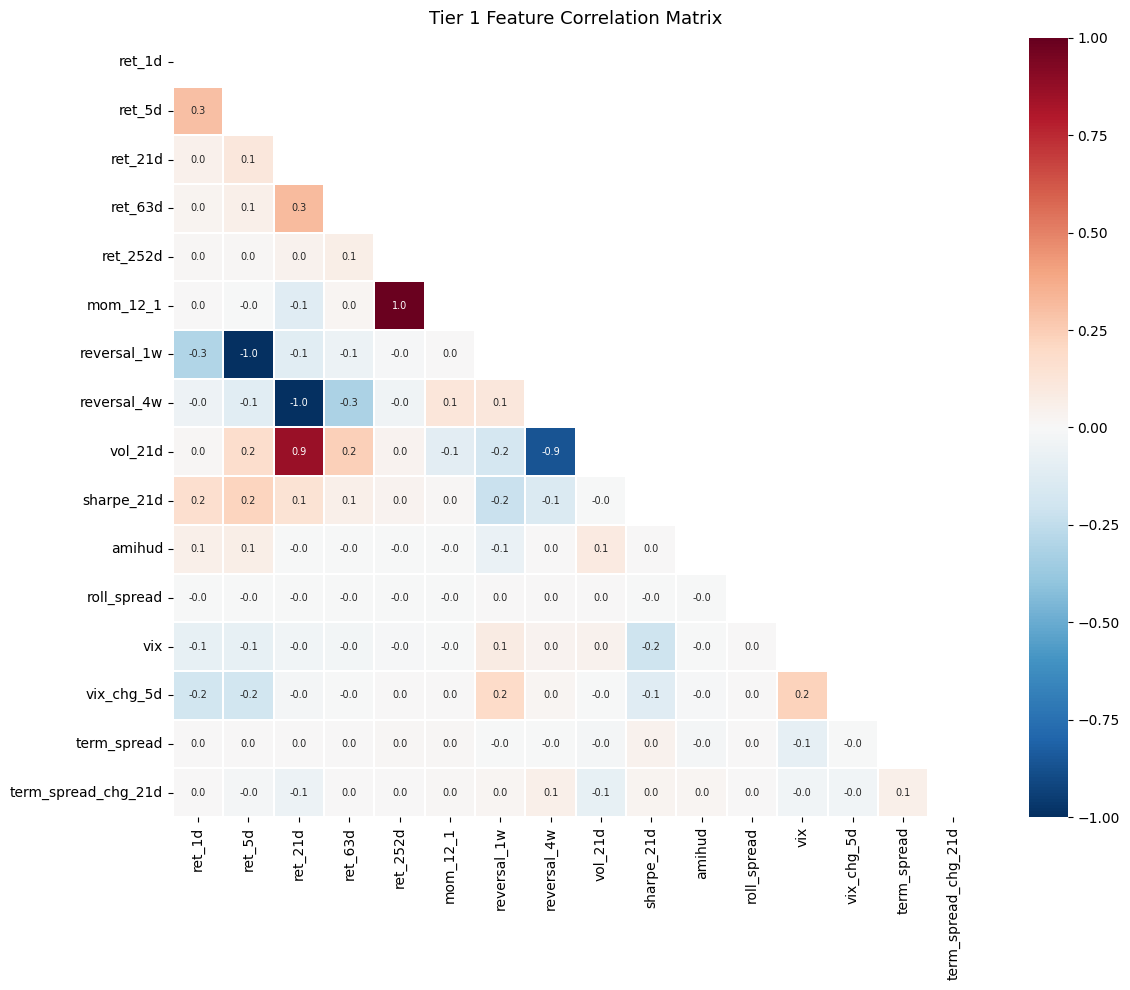

High-correlation pairs (|r| > 0.8): 5
  ret_5d               ↔ reversal_1w           r=-1.0
  ret_21d              ↔ reversal_4w           r=-1.0
  ret_21d              ↔ vol_21d               r=0.86
  ret_252d             ↔ mom_12_1              r=0.986
  reversal_4w          ↔ vol_21d               r=-0.86


In [5]:
# Sample 50k rows for correlation (full matrix is too slow)
sample = feat[feat_cols].dropna().sample(min(50_000, len(feat)), random_state=42)
corr = sample.corr()

# Flag high-correlation pairs
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        v = corr.iloc[i, j]
        if abs(v) > 0.8:
            high_corr.append((corr.index[i], corr.columns[j], round(v, 3)))

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.1f', linewidths=0.3, ax=ax, annot_kws={'size': 7})
ax.set_title('Tier 1 Feature Correlation Matrix', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/feature_correlation.png', dpi=120)
plt.show()

print(f'High-correlation pairs (|r| > 0.8): {len(high_corr)}')
for a, b, r in high_corr:
    print(f'  {a:20s} ↔ {b:20s}  r={r}')


## 5. Summary Stats Table

In [6]:
summary = feat[feat_cols].describe().T[['mean','std','min','25%','50%','75%','max']]
summary.columns = ['mean','std','min','p25','p50','p75','max']
print(summary.round(4).to_string())

# Save
summary.to_csv(f'{OUT_DIR}/feature_summary_stats.csv')
print(f'\nSaved feature_summary_stats.csv')
print(f'\nWeek 2 complete. features_tier1.parquet ready for Week 3 (Tier 2) and Week 4 (baseline models).')


                        mean     std       min      p25      p50      p75         max
ret_1d                0.0010  0.2107   -0.9999  -0.0071   0.0005   0.0082    168.0815
ret_5d                0.0042  0.4070   -0.9999  -0.0178   0.0025   0.0222    182.0530
ret_21d               0.0183  0.9692   -0.9998  -0.0346   0.0096   0.0522    238.3032
ret_63d               0.0541  1.8967   -1.0000  -0.0524   0.0265   0.1035    927.5714
ret_252d              0.2046  4.1572   -1.0000  -0.0771   0.0845   0.2536   1771.7273
mom_12_1              0.1860  4.1979 -218.2548  -0.0754   0.0789   0.2384   1771.8409
reversal_1w          -0.0042  0.4070 -182.0530  -0.0222  -0.0025   0.0178      0.9999
reversal_4w          -0.0183  0.9692 -238.3032  -0.0522  -0.0096   0.0346      0.9998
vol_21d               0.3058  3.2003    0.0057   0.1615   0.2227   0.3156    582.3011
sharpe_21d            0.6756  3.4778  -20.4873  -1.7099   0.6877   3.0493     20.2769
amihud                0.0000  0.0011    0.0000   0.000